In [1]:
from src.run import load_dataset, build_dataloader
from dataclasses import dataclass
import pprint
import torch


@dataclass
class DiffusionLunarLanderArgs:
    environment: str = "LunarLander-v3"
    horizon: int = 100
    batch_size: int = 32
    num_epochs: int = 10
    print_every: int = 1
    eval_every: int = 1
    lr: float = 1e-3
    hidden_dim: int = 64
    scheduler: str = "ddpm"
    num_train_timesteps: int = 1000
    inference_batch_size: int = 1
    condition_on: str = "start_obs"
    model_type: str = "unet"
    model_target: str = "obs_act"
    device: str = "cuda:0" if torch.cuda.is_available() else "cpu"
    num_inference_steps: int = 50


args = DiffusionLunarLanderArgs()

config, minari_dataset, env = load_dataset(args, eval_env=True)
action_dim = config.action_dim
obs_dim = config.obs_dim
input_dim = (obs_dim + action_dim) * args.horizon
cond_dim = obs_dim * 2

dataloader, minari_dataset_stats = build_dataloader(minari_dataset, args)

model_path = "src/checkpoints/DIFFUSION_LunarLander-v3_unet_h100_e10_target-obs_act_cond-start_obs.pth"
pp = pprint.PrettyPrinter(indent=2)
print("Dataset configuration:")
pp.pprint(config)
print("Training arguments:")
pp.pprint(vars(args))

Dataset configuration:
LunarLanderConfig(env_name='LunarLander-v3',
                  dataset_name='Box2D/LunarLanderContinuous-v3/expert-v0',
                  obs_dim=8,
                  action_dim=2,
                  category='Box2D')
Training arguments:
{ 'batch_size': 32,
  'condition_on': 'start_obs',
  'device': 'cpu',
  'environment': 'LunarLander-v3',
  'eval_every': 1,
  'hidden_dim': 64,
  'horizon': 100,
  'inference_batch_size': 1,
  'lr': 0.001,
  'model_target': 'obs_act',
  'model_type': 'unet',
  'num_epochs': 10,
  'num_inference_steps': 50,
  'num_train_timesteps': 1000,
  'print_every': 1,
  'scheduler': 'ddpm'}


In [2]:
from src.models.backbone import ConditionalUNet1D

print(f"Loading model from {model_path}...")
state_dict = torch.load(model_path, map_location=args.device)
model = ConditionalUNet1D(
    horizon=args.horizon,
    input_dim=input_dim,
    hidden_dim=args.hidden_dim,
    cond_dim=config.obs_dim,
).to(args.device)
model.load_state_dict(state_dict)

pp.pprint(minari_dataset_stats)


Loading model from src/checkpoints/DIFFUSION_LunarLander-v3_unet_h100_e10_target-obs_act_cond-start_obs.pth...
{ 'act_mean': tensor([-0.0589,  0.0307]),
  'act_std': tensor([0.4963, 0.4089]),
  'obs_mean': tensor([-7.9411e-02,  4.9357e-01, -2.3875e-02, -1.8714e-01, -2.0999e-03,
        -4.9274e-05,  1.7176e-01,  1.6406e-01]),
  'obs_std': tensor([0.1549, 0.4571, 0.2199, 0.1269, 0.1054, 0.0798, 0.3772, 0.3703]),
  'rew_mean': tensor(248.3491),
  'rew_std': tensor(39.7007)}


(<Figure size 1000x700 with 1 Axes>,
 <Axes: title={'center': 'Trajectory Visualization'}>)

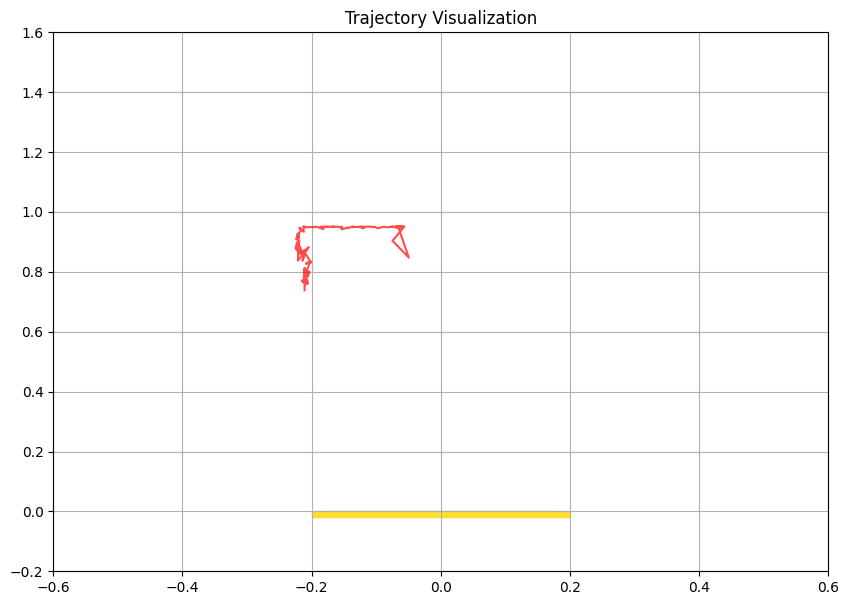

In [10]:
from src.pipelines.eval import evaluate_open_loop_diffusion
from src.diffusion import scheduler_map
noise_scheduler = scheduler_map[args.scheduler](args.num_train_timesteps)
evaluate_open_loop_diffusion(
    env=env,
    model=model,
    noise_scheduler=noise_scheduler,
    stats=minari_dataset_stats,
    input_dim= input_dim,
    args= args,
    logger=None
)